In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import librosa as lb
import soundfile as sf
import os
import matplotlib.pyplot as plt

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

from smart_stethoscope.ml_logic import data_loading

In [4]:
data_loading.load_data()


Extracting respiratory cycles from audio...

✅ Processed 6898 audio files

Load data from raw data folder...


,start,end,crackles,wheezes,filename,chest_location,cycle_filename,disease,age,sex,adult_bmi,child_weight,child_height
0,0.022,0.364,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_0,URTI,4.0,M,NaN,33.0,110.0
1,0.364,2.436,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_1,URTI,4.0,M,NaN,33.0,110.0
2,2.436,4.636,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_2,URTI,4.0,M,NaN,33.0,110.0
3,4.636,6.793,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_3,URTI,4.0,M,NaN,33.0,110.0
4,6.793,8.750,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_4,URTI,4.0,M,NaN,33.0,110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6893,16.946,19.156,1,0,130_2b3_Al_mc_AKGC417L,Al,130_2b3_Al_mc_AKGC417L_8,COPD,85.0,F,17.10,NaN,NaN
6894,0.022,3.450,0,0,116_1b2_Pl_sc_Meditron,Pl,116_1b2_Pl_sc_Meditron_0,Bronchiectasis,56.0,M,28.58,NaN,NaN
6895,3.450,10.507,0,1,116_1b2_Pl_sc_Meditron,Pl,116_1b2_Pl_sc_Meditron_1,Bronchiectasis,56.0,M,28.58,NaN,NaN
6896,10.507,17.336,0,1,116_1b2_Pl_sc_Meditron,Pl,116_1b2_Pl_sc_Meditron_2,Bronchiectasis,56.0,M,28.58,NaN,NaN


In [5]:
audio_file_path = '../raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Al_sc_Meditron.wav'
annotation_file_path = '../raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Al_sc_Meditron.txt'
annotations=pd.read_csv(annotation_file_path,sep='\t',names=['start','end','crackles','weezels'])
audio, sr = lb.load(audio_file_path, sr=None)
from smart_stethoscope.interface import main
breathing_cycles_features = main.predict(audio, sr, annotations)


In [6]:
breathing_cycles_features.shape

(12, 13, 259)

In [18]:
test = data_loading.load_tabular_data()
test.head()

,start,end,crackles,wheezes,filename,pid,chest_location,disease,age,sex,adult_bmi,child_weight,child_height
0,0.022,0.364,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0
1,0.364,2.436,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0
2,2.436,4.636,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0
3,4.636,6.793,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0
4,6.793,8.750,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0


### Load Demographic and Diagnosis Data

In [4]:
path_demographic_data = '../raw_data/demographic_info.txt'
column_names = ['pid', 'age', 'sex', 'adult_BMI', 'child_weight', 'child_height']
demographic_data = pd.read_csv(path_demographic_data, names=column_names, sep=' ', header=None)

demographic_data.head()

,pid,age,sex,adult_BMI,child_weight,child_height
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0


In [6]:
demographic_data.isnull().sum()

pid              0
age              1
sex              1
adult_BMI       51
child_weight    82
child_height    84
dtype: int64

In [5]:
demographic_data.dtypes

pid               int64
age             float64
sex              object
adult_BMI       float64
child_weight    float64
child_height    float64
dtype: object

In [7]:
path_diagnosis_data = '../raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv'
col_names_diagnosis = ['pid', 'diagnosis']
diagnosis_data = pd.read_csv(path_diagnosis_data, header=None, names=col_names_diagnosis)

diagnosis_data.head()

,pid,diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [8]:
diagnosis_data.isnull().sum()

pid          0
diagnosis    0
dtype: int64

In [9]:
diagnosis_data.dtypes

pid           int64
diagnosis    object
dtype: object

### Load Audio Annotations

In [10]:
annotation_folder = '../raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/'

In [11]:
files = [file.split('.')[0] for file in os.listdir(annotation_folder) if file.endswith('.txt') ]
files[0]

'148_1b1_Al_sc_Meditron'

In [12]:
def getFilenameInfo(file):
    return file.split('_')

In [13]:
files_data=[]
for file in files:
    data=pd.read_csv(annotation_folder + file + '.txt',sep='\t',names=['start','end','crackles','weezels'])
    name_data=getFilenameInfo(file)
    data['pid']=name_data[0]
    data['chest_location']=name_data[2]
    data['mode']=name_data[-2]
    data['filename']=file
    files_data.append(data)
files_df=pd.concat(files_data)
files_df.reset_index()
files_df.head()

,start,end,crackles,weezels,pid,chest_location,mode,filename
0,0.022,0.364,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
1,0.364,2.436,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
2,2.436,4.636,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
3,4.636,6.793,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
4,6.793,8.750,0,0,148,Al,sc,148_1b1_Al_sc_Meditron


In [14]:
diagnosis_data.pid = diagnosis_data.pid.astype('int32')
files_df.pid = files_df.pid.astype('int32')
demographic_data.pid = demographic_data.pid.astype('int32')

In [15]:
data=pd.merge(files_df,diagnosis_data,on='pid')
data.head()

,start,end,crackles,weezels,pid,chest_location,mode,filename,diagnosis
0,0.022,0.364,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI
1,0.364,2.436,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI
2,2.436,4.636,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI
3,4.636,6.793,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI
4,6.793,8.750,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI


In [ ]:
os.makedirs('../raw_data/csv_data')
data.to_csv('../raw_data/csv_data/data.csv',index=False)

In [19]:
data.value_counts('diagnosis')

diagnosis
COPD              5746
Healthy            322
Pneumonia          285
URTI               243
Bronchiolitis      160
Bronchiectasis     104
LRTI                32
Asthma               6
Name: count, dtype: int64

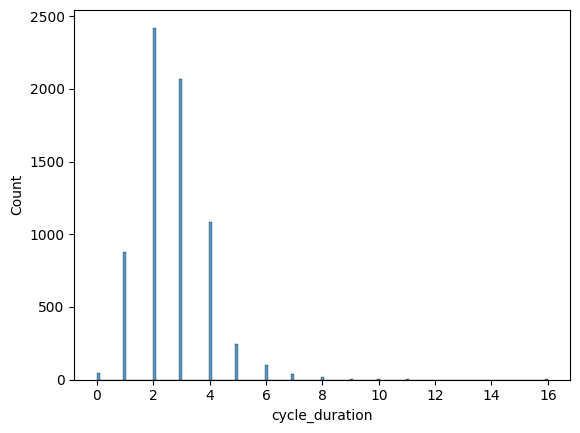

In [32]:
data['cycle_duration'] = data['end']-data['start']
sns.histplot(data=data, x=round(data['cycle_duration'],0));

### Preprocessing audio data

In [ ]:
preproc_audio_path = '../raw_data/preprocessed_audio_files/'
os.makedirs(preproc_audio_path)

In [ ]:
def getPureSample(raw_data,start,end,sr=22050):
    '''
    Takes a numpy array and spilts its using start and end args

    raw_data=numpy array of audio sample
    start=time
    end=time
    sr=sampling_rate
    mode=mono/stereo

    '''
    max_ind = len(raw_data)
    start_ind = min(int(start * sr), max_ind)
    end_ind = min(int(end * sr), max_ind)
    return raw_data[start_ind: end_ind]

In [ ]:

i,c=0,0
for index,row in data.iterrows():
    maxLen=6
    start=row['start']
    end=row['end']
    filename=row['filename']

    #If len > maxLen , change it to maxLen
    if end-start>maxLen:
        end=start+maxLen

    audio_file_loc=annotation_folder + filename + '.wav'

    if index > 0:
        #check if more cycles exits for same patient if so then add i to change filename
        if data.iloc[index-1]['filename']==filename:
            i+=1
        else:
            i=0
    filename= filename + '_' + str(i) + '.wav'

    save_path=preproc_audio_path + filename
    c+=1

    audioArr,sampleRate=lb.load(audio_file_loc)
    pureSample=getPureSample(audioArr,start,end,sampleRate)

    #pad audio if pureSample len < max_len
    reqLen = 6*sampleRate
    padded_data = lb.util.pad_center(data=pureSample, size=reqLen)

    sf.write(file=save_path,data=padded_data,samplerate=sampleRate)
print('Total Files Processed: ',c)

Total Files Processed:  6898


### Feature Extraction Experimenting

In [1]:
import IPython
IPython.display.Audio("../raw_data/preprocessed_audio_files/130_3p2_Tc_mc_AKGC417L_1.wav")

In [ ]:
import librosa.display as lbd
soundArr,sample_rate=lb.load("../raw_data/preprocessed_audio_files/130_3p2_Tc_mc_AKGC417L_1.wav")
mfcc=lb.feature.mfcc(y=soundArr,sr=sample_rate)
mel_spec = lb.feature.melspectrogram(y=soundArr, sr=sample_rate)
mfcc_val=np.array(mfcc)
mfcc_val

array([[-821.7861, -821.7861, -821.7861, ..., -821.7861, -821.7861,
        -821.7861],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       ...,
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ]], shape=(20, 259), dtype=float32)

[Text(0.5, 1.0, 'MFCC')]

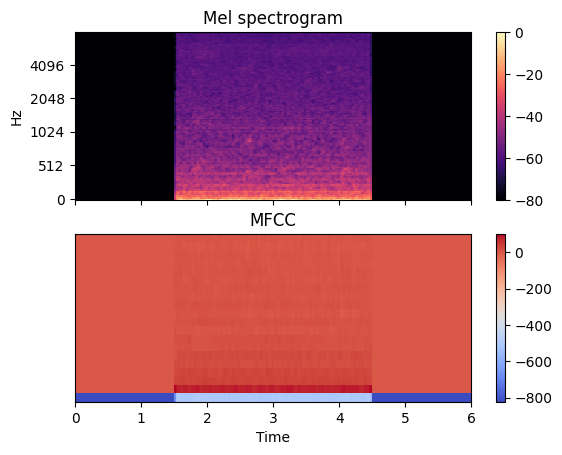

In [89]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, sharex=True)
img = lb.display.specshow(lb.power_to_db(mel_spec, ref=np.max),
                               x_axis='time', y_axis='mel', fmax=8000,
                               ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()
img = lb.display.specshow(mfcc, x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])
ax[1].set(title='MFCC')


### Check if any recording is not mono

In [93]:
import soundfile as sf

folder = annotation_folder

for f in os.listdir(folder):
    if f.endswith(".wav"):
        data, sr = sf.read(os.path.join(folder, f))
        if len(data.shape) >1:
            print(f, data.shape)

In [121]:
test = files_df[['pid', 'filename', 'mode']]
test = test[test['mode'] == 'mc']
test = test.drop_duplicates()
test['pid'].value_counts()
test[test['pid']==198]

,pid,filename,mode
0,198,198_6p1_Ll_mc_AKGC417L,mc
0,198,198_1b5_Ll_mc_AKGC417L,mc
0,198,198_1b5_Ar_mc_AKGC417L,mc
0,198,198_6p1_Ar_mc_AKGC417L,mc
0,198,198_6p1_Pr_mc_AKGC417L,mc
0,198,198_1b5_Pr_mc_AKGC417L,mc
0,198,198_6p1_Lr_mc_AKGC417L,mc
0,198,198_1b5_Lr_mc_AKGC417L,mc
0,198,198_1b5_Al_mc_AKGC417L,mc
0,198,198_6p1_Al_mc_AKGC417L,mc


In [12]:
from smart_stethoscope.interface import main
X, mel_spectograms_array, y, groups = main.preprocessing()


Skipped blacklisted patient 142

Skipped blacklisted patient 182

Skipped blacklisted patient 191

Skipped blacklisted patient 191

Skipped blacklisted patient 191


In [17]:
X.shape

(3135, 42)

In [18]:
mel_spectograms_array.shape

(3135, 128, 200, 1)

In [20]:
audio, sr = lb.load("/Users/miameyer/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Al_sc_Meditron.wav")

In [23]:
features, mel_spectograms = main.preprocess_for_prediction(audio=audio, sampling_rate=sr, start=0.036, end=19.964)

In [25]:
mel_spectograms.shape

(3, 128, 200, 1)

In [24]:
features.head()

,rms_mean,rms_std,zcr_mean,centroid_mean,centroid_std,flatness_mean,flatness_std,rolloff_mean,bandwidth_mean,flux_mean,...,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,mfcc_14_mean,mfcc_14_std,mfcc_15_mean,mfcc_15_std
0,0.266194,0.039734,0.003969,159.479074,86.722154,0.000080,0.000330,215.342420,453.152477,0.418177,...,23.840946,5.975066,21.187138,6.681886,20.653869,5.936202,20.843892,5.270301,20.483855,5.199789
1,0.251057,0.037541,0.003802,151.654797,71.824383,0.000052,0.000143,196.559176,445.049824,0.371067,...,24.250600,4.916006,21.930107,5.110933,21.732180,5.588647,22.120228,6.163565,21.625132,6.239366
2,0.248584,0.038714,0.003619,166.931894,116.260947,0.000120,0.000501,232.671210,461.700974,0.394868,...,24.020732,7.413128,21.350478,6.557534,21.460391,6.188761,21.810217,8.671430,23.128308,9.127236
